# 강원도 산불 날씨-공간 융합 시각화 EDA (Weather-Spatial Fusion EDA)

## 1. 분석 개요 및 배경
- 본 분석은 이전 단계에서 각각 독립적으로 수행되었던 **날씨 기상 인자 분석**과 **순수 공간 지형/인프라 분석**의 결과를 다차원적으로 결합한 **날씨-공간 융합 시각화 EDA**이다.
- 사용자의 지침에 따라 어떠한 머신러닝 예측 모델링이나 복합 위험 지수(WFRI, FSI) 계산을 수행하지 않고, 오직 데이터의 결합 관계를 직관적으로 가시화하는 고품질 차트와 통계 검정 단계에만 집중한다.
- **주요 분석 주제**:
  1. **공간 유형(인간 활동권 vs 산림 산악권)에 따른 발화 날씨 임계치 대조**: 도로변/건물 피복 위에서 실화로 시작된 '일반번지 산불'과 깊은 산림 및 등산로 인접지에서 시작된 '임야번지 산불'이 발생할 당시의 날씨 조건(습도, 풍속, 강수량)을 대조 시각화한다. 이를 통해 "인간 활동 지역은 덜 건조하거나 풍속이 약한 일상적인 날씨에서도 산불이 쉽게 발화하는지"를 통계적으로 증명한다.
  2. **강원도 전역 DEM 지형(고도) 대비 산불 발생 지점의 고도 이례성 검정**: 산불 발생지의 고도 분포와 강원도 전체 지형(DEM 래스터의 10,000개 무작위 샘플)의 고도 분포를 오버레이 시각화하여, 산불이 일어나는 산악 고도가 강원도 전체의 고도 분포상 얼마나 특이점을 보이는지 규명한다.
  3. **강원도 전역의 고도(DEM)에 따른 날씨 변화(상관성) 시각화**: 92개 기상 격자 셀의 중심점 고도와 2020~2021년 평균 기온, 풍속, 습도 간의 상관관계를 산포도와 회귀선으로 나타내어 고도에 따른 기후 특성(기온 감률 및 산지 강풍대 분포)을 시각적으로 규명한다.
  4. **날씨-지형 복합 3D 다차원 버블 차트**: 고도(X축), 발생 시각 상대습도(Y축), 풍속(버블의 크기 및 색상)을 조합하여, 두 번지 집단이 발화되는 날씨-지형의 복합적 결합 영역을 3차원 평면으로 대조 시각화한다.


In [1]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import rasterio
from scipy import stats
from pathlib import Path
import time

try:
    from IPython.display import display, Markdown
except ImportError:
    display = print
    def Markdown(text):
        return text

# 한글 폰트 설정 (맑은 고딕)
font_path = 'C:/Windows/Fonts/malgun.ttf'
if Path(font_path).exists():
    fm.fontManager.addfont(font_path)
    font_name = fm.FontProperties(fname=font_path).get_name()
else:
    font_name = 'DejaVu Sans'

sns.set_theme(
    style='whitegrid',
    font=font_name,
    rc={
        'font.family': font_name,
        'font.sans-serif': [font_name],
        'axes.unicode_minus': False,
    },
)
plt.rcParams['font.family'] = font_name
plt.rcParams['font.sans-serif'] = [font_name]
plt.rcParams['axes.unicode_minus'] = False
pd.set_option('display.max_columns', None)

ROOT = Path('D:/farm-system-public-02')
DATA_DIR = ROOT / 'data'
FIRE_DIR = DATA_DIR / '강원도_데이터'
SPATIAL_DIR = FIRE_DIR / '강원도_공간데이터'
FIRE_SPATIAL_DIR = FIRE_DIR / '산불_공간데이터'
WEATHER_DIR = DATA_DIR / '강원도_날씨데이터'

print('ROOT Directory:', ROOT)
print('Matplotlib 한글 폰트 설정 완료:', plt.rcParams['font.family'])


ROOT Directory: D:\farm-system-public-02
Matplotlib 한글 폰트 설정 완료: ['Malgun Gothic']


## 2. 데이터 로드 및 날씨-공간 다차원 결합
- 산불 발생 데이터와 날씨(일단위, 시간단위) 데이터를 기상 격자 폴리곤(`gpd.sjoin`) 및 날짜/시간 인덱스를 매칭하여 다차원 결합을 수행한다.
- 산불 주소명 번지 기준(`임야번지(산)` vs `일반번지`) 이분화 파생 변수 생성을 통해 공간적 원인 구분을 정의한다.
- 강원도 전체 지형 분포를 샘플링하기 위해 `강원도_DEM_데이터.tif` 래스터 파일에서 경계 내 10,000개 포인트를 랜덤 추출하여 고도(Elevation) 분포를 수집한다.


In [2]:
t0 = time.time()

# 1. 산불 및 지형 특성 병합 로드
print('1) 강원도 산불 발생 및 지형 특성 데이터 로드...')
fire_df = pd.read_csv(FIRE_DIR / '강원도_산불발생.csv', encoding='utf-8')
topo_df = pd.read_csv(FIRE_SPATIAL_DIR / '강원도_산불_지형특성계산.csv', encoding='utf-8')
fire_df = fire_df.merge(
    topo_df[['fire_id', '고도(m)', '경사도(도)', '사면방향_sin', '사면방향_cos', 'TPI(지형위치지수)', 'TWI(지형다습지수)']],
    on='fire_id',
    how='inner'
)
fire_df.loc[fire_df['TWI(지형다습지수)'] > 1e8, 'TWI(지형다습지수)'] = np.nan
fire_df['is_mountain_address'] = fire_df['발생지역번지'].astype(str).str.contains('산')
fire_df['addr_type'] = fire_df['is_mountain_address'].map({True: '임야번지(산)', False: '일반번지'})

# 2. 공간 GIS 조인을 위해 GeoDataFrame 변환
fire_gdf = gpd.GeoDataFrame(
    fire_df,
    geometry=gpd.points_from_xy(fire_df['경도'], fire_df['위도']),
    crs='EPSG:4326'
).to_crs('EPSG:5186')

# 3. 기상 격자 지도 및 일단위/시간단위 날씨 로드
print('2) 기상 격자 및 보간 날씨 데이터 로드...')
grid_gdf = gpd.read_file(WEATHER_DIR / '강원도날씨_격자.geojson').to_crs('EPSG:5186')
weather_day = pd.read_csv(WEATHER_DIR / '강원도날씨_격자_일단위.csv', encoding='utf-8')
weather_hour = pd.read_csv(WEATHER_DIR / '강원도날씨_격자_시간단위.csv', encoding='utf-8')

# 4. 산불 발생 위치 기상셀 매핑 (Spatial Join)
print('3) 산불 포인트와 기상 셀 공간 조인...')
fire_gdf = gpd.sjoin(fire_gdf, grid_gdf[['기상셀ID', 'geometry']], how='left', predicate='within').drop(columns=['index_right'])
fire_gdf = fire_gdf.drop_duplicates(subset='fire_id', keep='first').reset_index(drop=True)

# 5. 날씨 조인을 위한 발생일 포맷 가공
fire_gdf['날짜'] = fire_gdf['연도'].astype(str) + '-' + fire_gdf['월'].astype(str).str.zfill(2) + '-' + fire_gdf['일'].astype(str).str.zfill(2)
fire_gdf['일시'] = fire_gdf['날짜'] + ' ' + fire_gdf['시간'].astype(str).str.zfill(2) + ':00'

# 6. 발생 당일 일날씨 병합
print('4) 산불 시점의 격자별 일날씨/시간날씨 결합...')
fire_gdf = fire_gdf.merge(
    weather_day[['기상셀ID', '날짜', '평균기온_C', '최저기온_C', '최고기온_C', '강수량_mm', '최대순간풍속_m_s']],
    on=['기상셀ID', '날짜'],
    how='left'
)

# 7. 발생 시간대 시간날씨(습도, 풍속) 병합
fire_gdf = fire_gdf.merge(
    weather_hour[['기상셀ID', '일시', '습도_pct', '풍속_m_s']],
    on=['기상셀ID', '일시'],
    how='left'
)

# 8. 강원도 전체 DEM 10,000개 무작위 고도 샘플링
print('5) 강원도 전체 DEM 데이터(래스터) 무작위 10,000개 고도 샘플링...')
with rasterio.open(SPATIAL_DIR / '강원도_DEM_데이터.tif') as src:
    dem_arr = src.read(1)
    nodata = src.nodata if src.nodata is not None else -9999
    # 유효 영역의 래스터 픽셀 인덱스 수집
    valid_coords = np.argwhere((dem_arr > nodata) & (dem_arr < 9000) & (dem_arr > -100))
    np.random.seed(42) # 재현성을 위한 시드 설정
    sample_indices = np.random.choice(len(valid_coords), 10000, replace=False)
    sampled_pixels = valid_coords[sample_indices]
    # 고도 샘플 추출
    sampled_dem = dem_arr[sampled_pixels[:, 0], sampled_pixels[:, 1]]
    
    # 92개 기상 격자 중심점의 고도 데이터도 추출 (고도-날씨 상관성 시각화용)
    grid_centroids = [(geom.centroid.x, geom.centroid.y) for geom in grid_gdf.geometry]
    grid_gdf['고도_m'] = [val[0] for val in src.sample(grid_centroids)]

t1 = time.time()
print(f'\n>>> 기상-공간 다차원 데이터 융합 완료 (소요시간: {t1-t0:.2f}초)')
print(f'- 결합된 융합 산불 데이터셋 크기: {fire_gdf.shape}')
print(f'- 강원도 전역 DEM 샘플 크기: {sampled_dem.shape}')


1) 강원도 산불 발생 및 지형 특성 데이터 로드...
2) 기상 격자 및 보간 날씨 데이터 로드...
3) 산불 포인트와 기상 셀 공간 조인...
4) 산불 시점의 격자별 일날씨/시간날씨 결합...
5) 강원도 전체 DEM 데이터(래스터) 무작위 10,000개 고도 샘플링...

>>> 기상-공간 다차원 데이터 융합 완료 (소요시간: 1.80초)
- 결합된 융합 산불 데이터셋 크기: (3405, 35)
- 강원도 전역 DEM 샘플 크기: (10000,)


## 3. 공간 발화 유형에 따른 기상 조건(습도·풍속·강수) 비교 시각화
- **인위적 활동권(일반번지)** 산불과 **자연/깊은 임야 산림권(임야번지)** 산불 발생 시점의 기상 요소들의 분포 차이를 대조한다.
- **시각화 구성**: 발생 시각 상대습도(`습도_pct`), 발생일 최대순간풍속(`최대순간풍속_m_s`), 발생 당일 강수량(`강수량_mm`)에 대해 **3 x 2 Subplots** (상자그림 및 확률밀도함수 KDE) 형태로 비교한다.
- **통계 검정**: 두 그룹 간 기상 임계치(Threshold)의 차이가 통계적으로 유의미한지 Mann-Whitney U 검정 및 Cohen's d 효과크기를 병행한다. 이를 통해 "일반번지(인간 활동 근처)는 덜 건조하거나 바람이 적게 부는 평이한 날씨 상태에서도 화재가 쉽게 시작되는가"에 대한 실화 중심 가설을 규명한다.


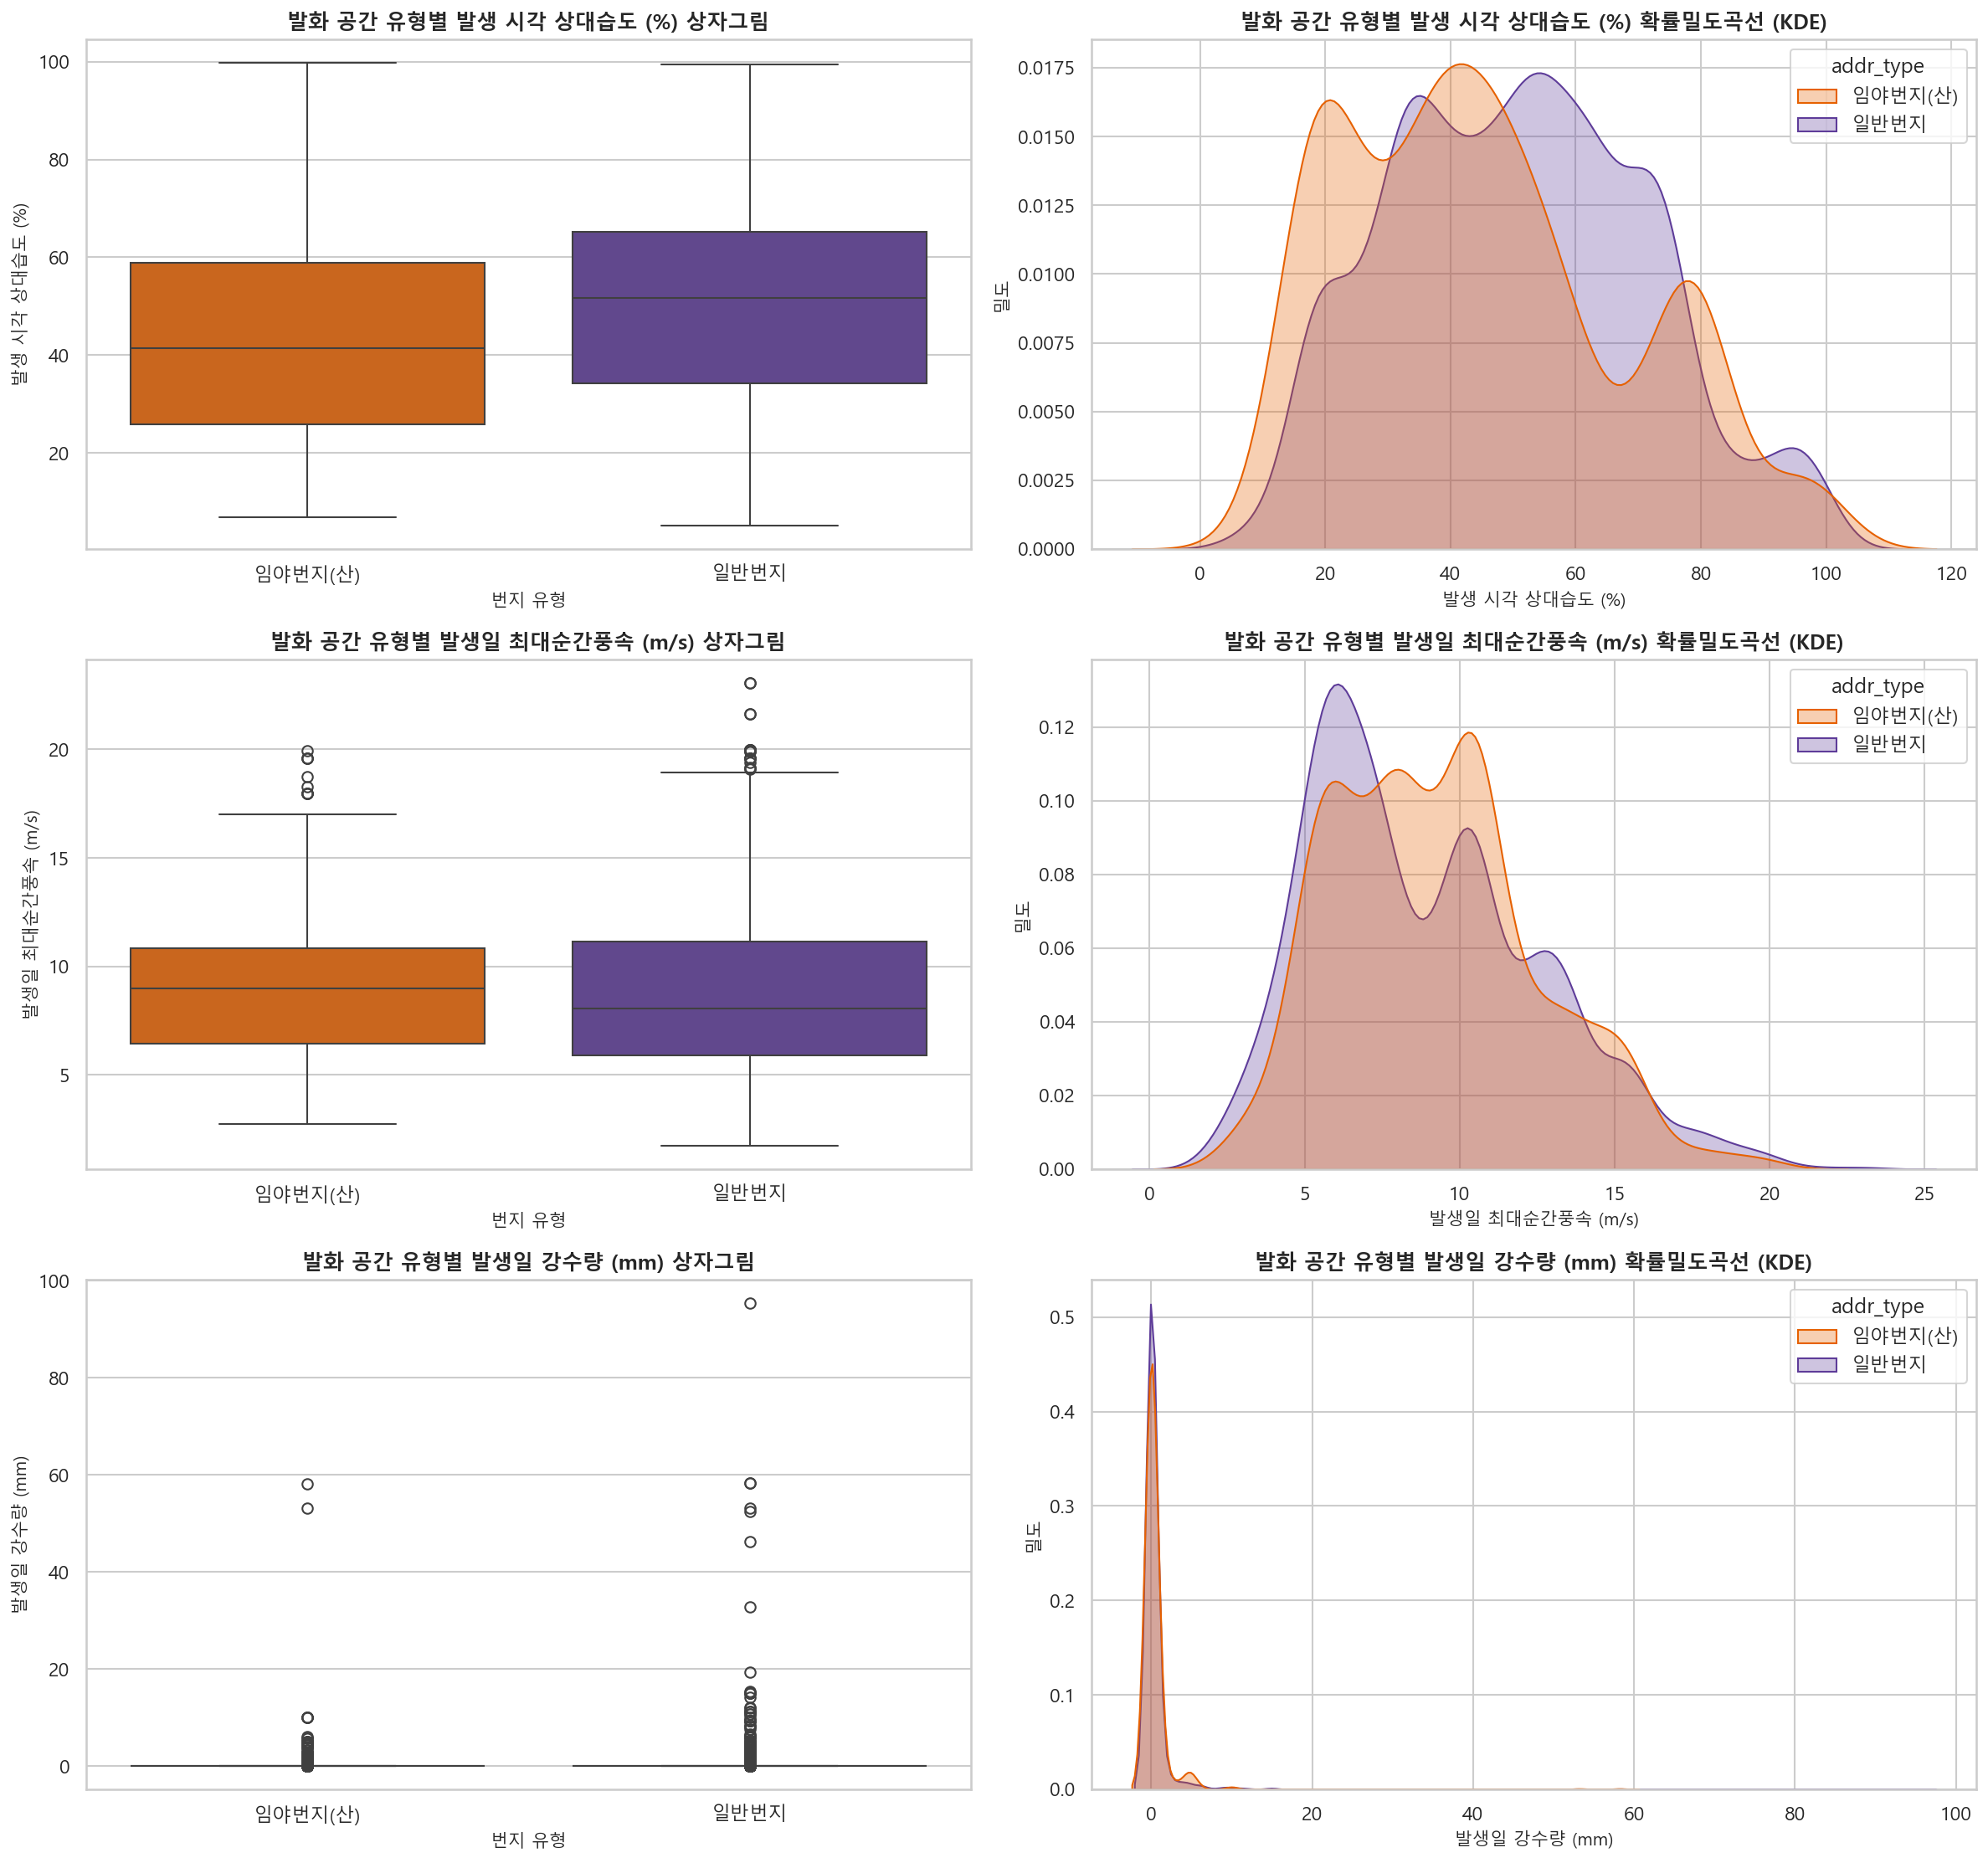

### 발화 공간 유형 간 기상 요소 통계 검정 요약

,기상 변수,임야_중앙값,일반_중앙값,p-value,효과크기 (Cohen's d)
0,발생 시각 상대습도 (%),41.49,51.75,1.267889e-11,-0.258326
1,발생일 최대순간풍속 (m/s),8.99,8.05,1.373870e-03,0.083197
2,발생일 강수량 (mm),0.00,0.00,2.167374e-02,-0.002277


In [3]:
weather_vars = {
    '습도_pct': '발생 시각 상대습도 (%)',
    '최대순간풍속_m_s': '발생일 최대순간풍속 (m/s)',
    '강수량_mm': '발생일 강수량 (mm)'
}

palette = {'임야번지(산)': '#E66101', '일반번지': '#5E3C99'}
order = ['임야번지(산)', '일반번지']

fig, axes = plt.subplots(3, 2, figsize=(16, 15), dpi=150)

group_m = fire_gdf[fire_gdf['addr_type'] == '임야번지(산)']
group_g = fire_gdf[fire_gdf['addr_type'] == '일반번지']

weather_stats = []

for idx, (col, label) in enumerate(weather_vars.items()):
    # 1. Boxplot
    sns.boxplot(
        data=fire_gdf,
        x='addr_type',
        y=col,
        order=order,
        palette=palette,
        ax=axes[idx, 0]
    )
    axes[idx, 0].set_title(f'발화 공간 유형별 {label} 상자그림', fontsize=12, fontweight='bold')
    axes[idx, 0].set_xlabel('번지 유형', fontsize=10)
    axes[idx, 0].set_ylabel(label, fontsize=10)
    
    # 2. KDE Plot
    sns.kdeplot(
        data=fire_gdf,
        x=col,
        hue='addr_type',
        hue_order=order,
        palette=palette,
        fill=True,
        alpha=0.3,
        common_norm=False,
        ax=axes[idx, 1]
    )
    axes[idx, 1].set_title(f'발화 공간 유형별 {label} 확률밀도곡선 (KDE)', fontsize=12, fontweight='bold')
    axes[idx, 1].set_xlabel(label, fontsize=10)
    axes[idx, 1].set_ylabel('밀도', fontsize=10)
    
    # 가설검정 및 효과크기
    m_vals = group_m[col].dropna().values
    g_vals = group_g[col].dropna().values
    
    u_stat, p_val = stats.mannwhitneyu(m_vals, g_vals, alternative='two-sided')
    pooled_std = np.sqrt(((len(m_vals) - 1) * np.var(m_vals, ddof=1) + (len(g_vals) - 1) * np.var(g_vals, ddof=1)) / (len(m_vals) + len(g_vals) - 2))
    d_val = (np.mean(m_vals) - np.mean(g_vals)) / pooled_std if pooled_std > 0 else 0.0
    
    weather_stats.append({
        '기상 변수': label,
        '임야_평균': np.mean(m_vals),
        '일반_평균': np.mean(g_vals),
        '임야_중앙값': np.median(m_vals),
        '일반_중앙값': np.median(g_vals),
        'p-value': p_val,
        '효과크기 (Cohen\'s d)': d_val
    })

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'fusion_eda_weather_contrast.png', dpi=300)
plt.show()

weather_stats_df = pd.DataFrame(weather_stats)
display(Markdown('### 발화 공간 유형 간 기상 요소 통계 검정 요약'))
display(weather_stats_df[['기상 변수', '임야_중앙값', '일반_중앙값', 'p-value', '효과크기 (Cohen\'s d)']])


- 임야 산불은 전형적인 건조 산불, 일반 번지는 인간 활동의 영향 가능성
- 순간 풍속과 강수량은 별 차이 없어 보임

## 4. 강원도 전체 지형(DEM) 분포 대비 산불 발생지의 지형 이례성 분석
- **분석 목적**: 강원도 산불 발생지 고도 분포와 강원도 전체 래스터 고도 분포의 차이를 입증하여, 산불이 강원도의 지리적 지형 틀 안에서 어떤 고도 영역에 쏠려 나타나는가(이례성)를 분석한다.
- **시각화 구성**: `1행 2열 Subplots`로 고도 비교를 표현한다.
  - **좌측 (KDE)**: 강원도 전체 DEM 샘플 10,000개의 고도 분포 곡선(연그레이 채움)과 실제 산불 발생지 3,405곳의 고도 분포 곡선(적색 채움)을 겹쳐 그려 두 분포의 형태적 대조를 시각화한다.
  - **우측 (ECDF)**: 고도별 누적 거동 곡선(ECDF)의 기울기 격차를 확인한다.
- **통계 검정**: 강원도 전역 평균 지형과 산불 발생지의 고도값 간 비모수 가설검정 및 효과크기를 산출해 산불 유발 지형의 유의한 지리적 편향성을 수치로 확립한다.


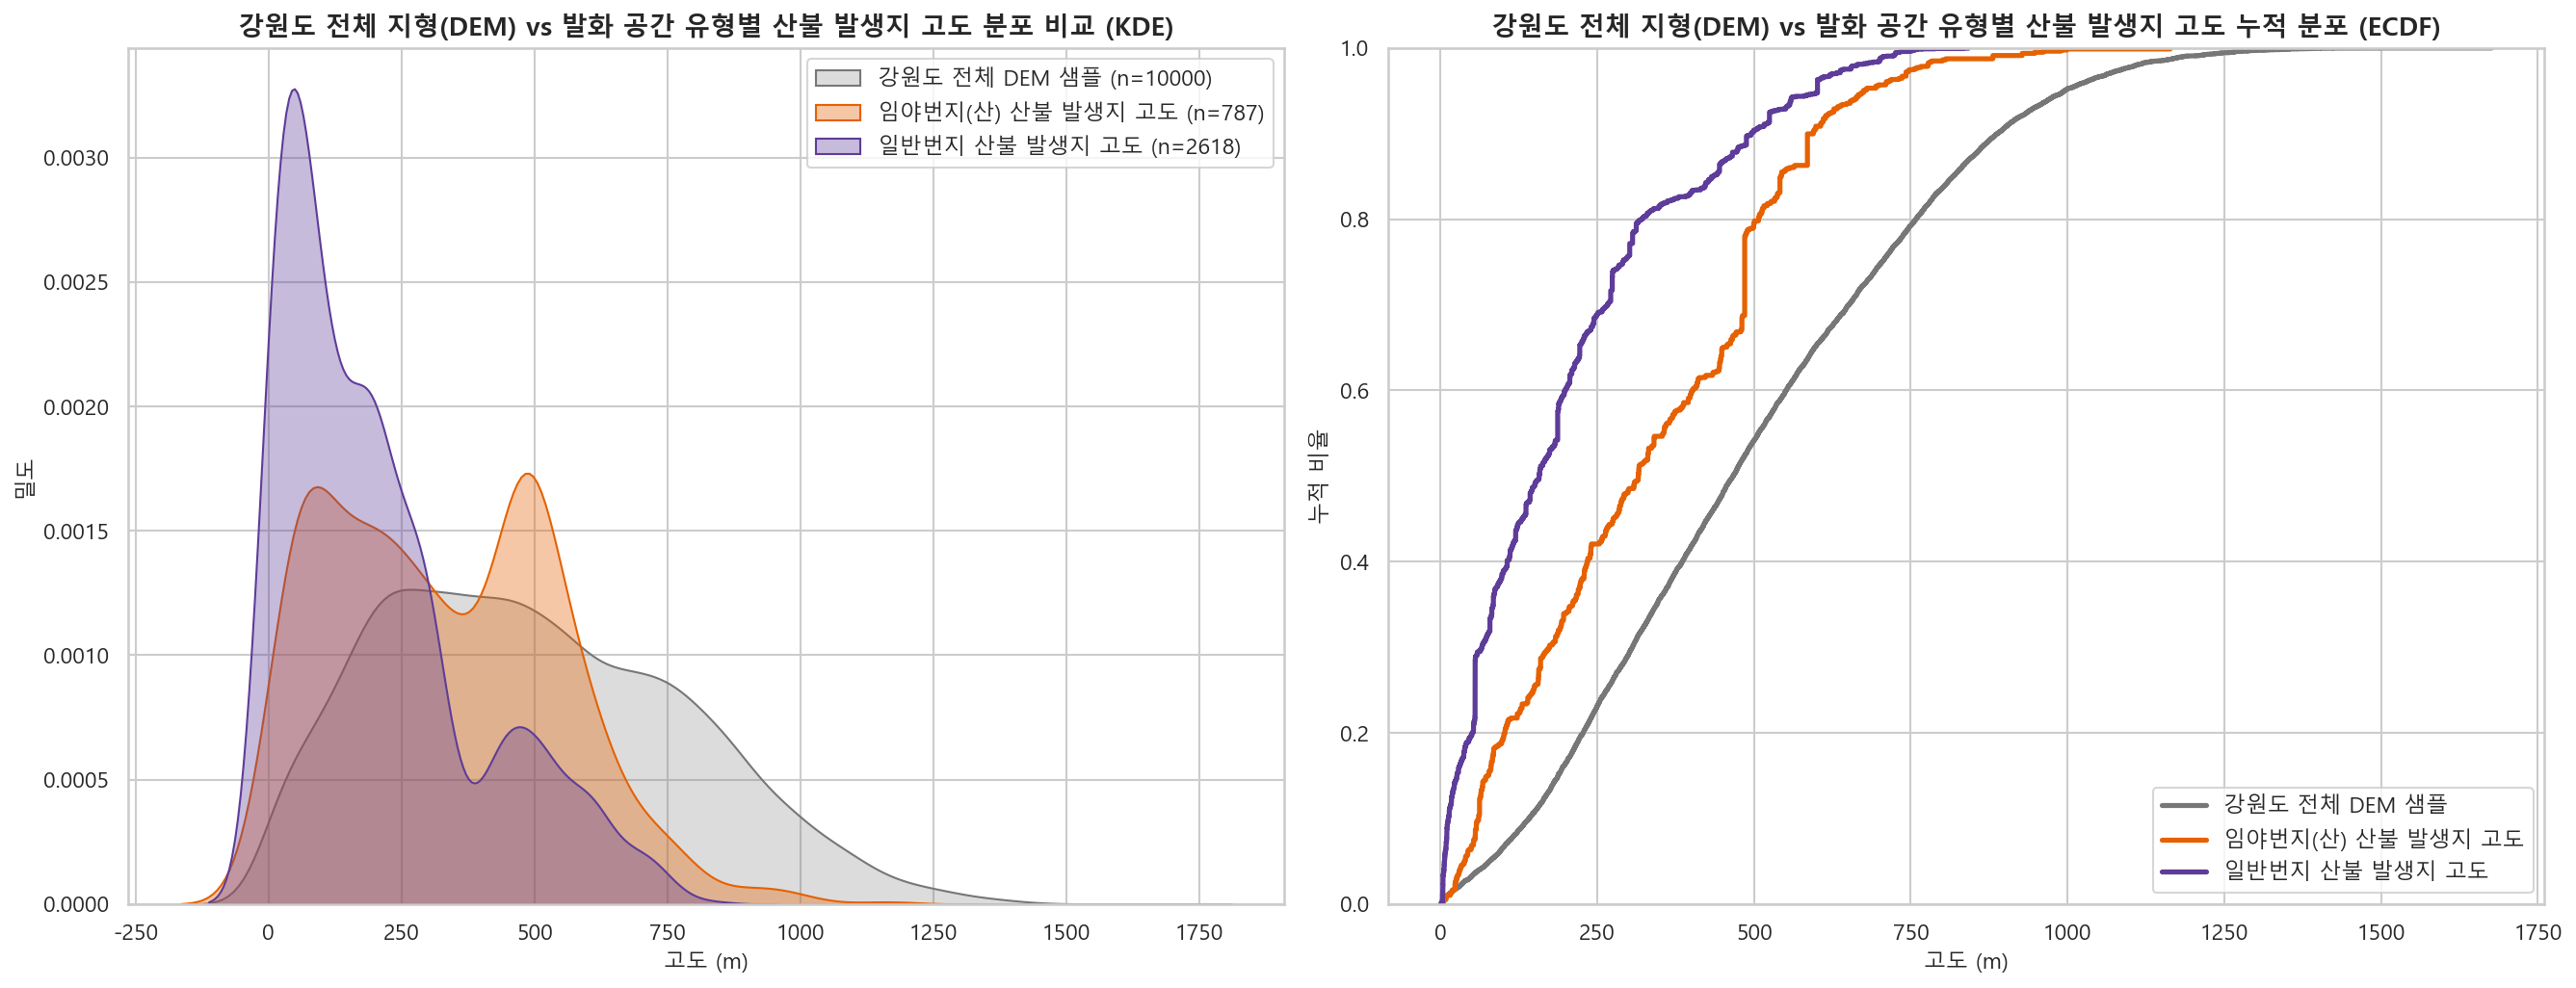

### 강원도 전체 지형 대비 발화 공간 유형별 산불 발생지 고도 검정 결과

,비교 집단,DEM 평균(m),DEM 중앙값(m),임야번지(산) 평균(m),임야번지(산) 중앙값(m),p-value,효과크기 (Cohen's d),일반번지 평균(m),일반번지 중앙값(m)
0,임야번지(산) 산불 발생지 vs 강원도 전체 DEM,495.411713,466.648926,329.83366,315.54663,1.231507e-54,-0.589552,NaN,NaN
1,일반번지 산불 발생지 vs 강원도 전체 DEM,495.411713,466.648926,NaN,NaN,0.000000e+00,-1.094847,202.651378,157.42416


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(18, 7), dpi=150)

palette = {
    '강원도 전체 DEM 샘플': '#777777',
    '임야번지(산)': '#E66101',
    '일반번지': '#5E3C99'
}

fire_m = fire_gdf[fire_gdf['addr_type'] == '임야번지(산)']['고도(m)'].dropna()
fire_g = fire_gdf[fire_gdf['addr_type'] == '일반번지']['고도(m)'].dropna()

# 1. KDE 비교
sns.kdeplot(
    sampled_dem,
    fill=True,
    color=palette['강원도 전체 DEM 샘플'],
    alpha=0.25,
    label=f'강원도 전체 DEM 샘플 (n={len(sampled_dem)})',
    common_norm=False,
    ax=axes[0]
)

sns.kdeplot(
    fire_m,
    fill=True,
    color=palette['임야번지(산)'],
    alpha=0.35,
    label=f'임야번지(산) 산불 발생지 고도 (n={len(fire_m)})',
    common_norm=False,
    ax=axes[0]
)

sns.kdeplot(
    fire_g,
    fill=True,
    color=palette['일반번지'],
    alpha=0.35,
    label=f'일반번지 산불 발생지 고도 (n={len(fire_g)})',
    common_norm=False,
    ax=axes[0]
)

axes[0].set_title('강원도 전체 지형(DEM) vs 발화 공간 유형별 산불 발생지 고도 분포 비교 (KDE)',
                  fontsize=13, fontweight='bold')
axes[0].set_xlabel('고도 (m)', fontsize=11)
axes[0].set_ylabel('밀도', fontsize=11)
axes[0].legend(loc='upper right', frameon=True)


# 2. ECDF 비교
sns.ecdfplot(
    sampled_dem,
    color=palette['강원도 전체 DEM 샘플'],
    lw=2.5,
    label='강원도 전체 DEM 샘플',
    ax=axes[1]
)

sns.ecdfplot(
    fire_m,
    color=palette['임야번지(산)'],
    lw=2.5,
    label='임야번지(산) 산불 발생지 고도',
    ax=axes[1]
)

sns.ecdfplot(
    fire_g,
    color=palette['일반번지'],
    lw=2.5,
    label='일반번지 산불 발생지 고도',
    ax=axes[1]
)

axes[1].set_title('강원도 전체 지형(DEM) vs 발화 공간 유형별 산불 발생지 고도 누적 분포 (ECDF)',
                  fontsize=13, fontweight='bold')
axes[1].set_xlabel('고도 (m)', fontsize=11)
axes[1].set_ylabel('누적 비율', fontsize=11)
axes[1].legend(loc='lower right', frameon=True)

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'fusion_eda_dem_contrast_by_addr_type.png', dpi=300)
plt.show()

dem_stats = []

for name, values in {
    '임야번지(산)': fire_m,
    '일반번지': fire_g
}.items():
    u_stat, p_val = stats.mannwhitneyu(
        values.values,
        sampled_dem,
        alternative='two-sided'
    )

    pooled_std = np.sqrt(
        ((len(values) - 1) * np.var(values, ddof=1) +
         (len(sampled_dem) - 1) * np.var(sampled_dem, ddof=1)) /
        (len(values) + len(sampled_dem) - 2)
    )

    d_val = (np.mean(values) - np.mean(sampled_dem)) / pooled_std

    dem_stats.append({
        '비교 집단': f'{name} 산불 발생지 vs 강원도 전체 DEM',
        'DEM 평균(m)': np.mean(sampled_dem),
        'DEM 중앙값(m)': np.median(sampled_dem),
        f'{name} 평균(m)': np.mean(values),
        f'{name} 중앙값(m)': np.median(values),
        'p-value': p_val,
        "효과크기 (Cohen's d)": d_val
    })

dem_by_addr_stats_df = pd.DataFrame(dem_stats)

display(Markdown('### 강원도 전체 지형 대비 발화 공간 유형별 산불 발생지 고도 검정 결과'))
display(dem_by_addr_stats_df)

- 강원도라는 지형 자체와 비교했을 때, 산불은 어떤 고도에서 편향적으로 발생하는가
- 일반 산불은 강원도 전체 대비 저고도에서 집중적으로 발생하였다
- 임야는 저고도와 산 중턱에서 많이 발생하였다
  - 통계표를 보면 임야번지도 강원도 평균보다 유의하게 저고도 편향
  - 250~500m 구간 산불 비율이 움푹 들어가있다 -> 임야 산불 안에서도 다양한 매커니즘이 잇을 것이다

## 5. 강원도 전역의 지형 고도(DEM)에 따른 기상 조건의 상관성 시각화
- **분석 목적**: 해발고도(DEM)가 지형 기상 요소(기온, 풍속, 습도 등) 분포에 미치는 물리적 영향 관계를 강원도 격자 전체 관점에서 탐색한다.
- **시각화 구성**: 격자 중심점의 해발고도(X축)와 92개 기상 격자별 2020~2021년 전체 평균 날씨 변수(Y축) 간의 산포도 및 선형 회귀선(Regression line)을 **1행 3열 Subplots**로 시각화한다.
  - **서브플롯 1**: 해발고도 vs 2개년 평균 기온 (°C)
  - **서브플롯 2**: 해발고도 vs 2개년 평균 최대순간풍속 (m/s)
  - **서브플롯 3**: 해발고도 vs 2개년 평균 상대습도 (%)
- 각 상관관계 그래프 상에 Spearman 순위 상관계수($\rho$)와 유의수준(p-value)을 명시하여 고도 증가에 따른 기후 변동성 경향(고지대 기온 감률 및 강풍 노출 경향)을 통계적 시각으로 확립한다.


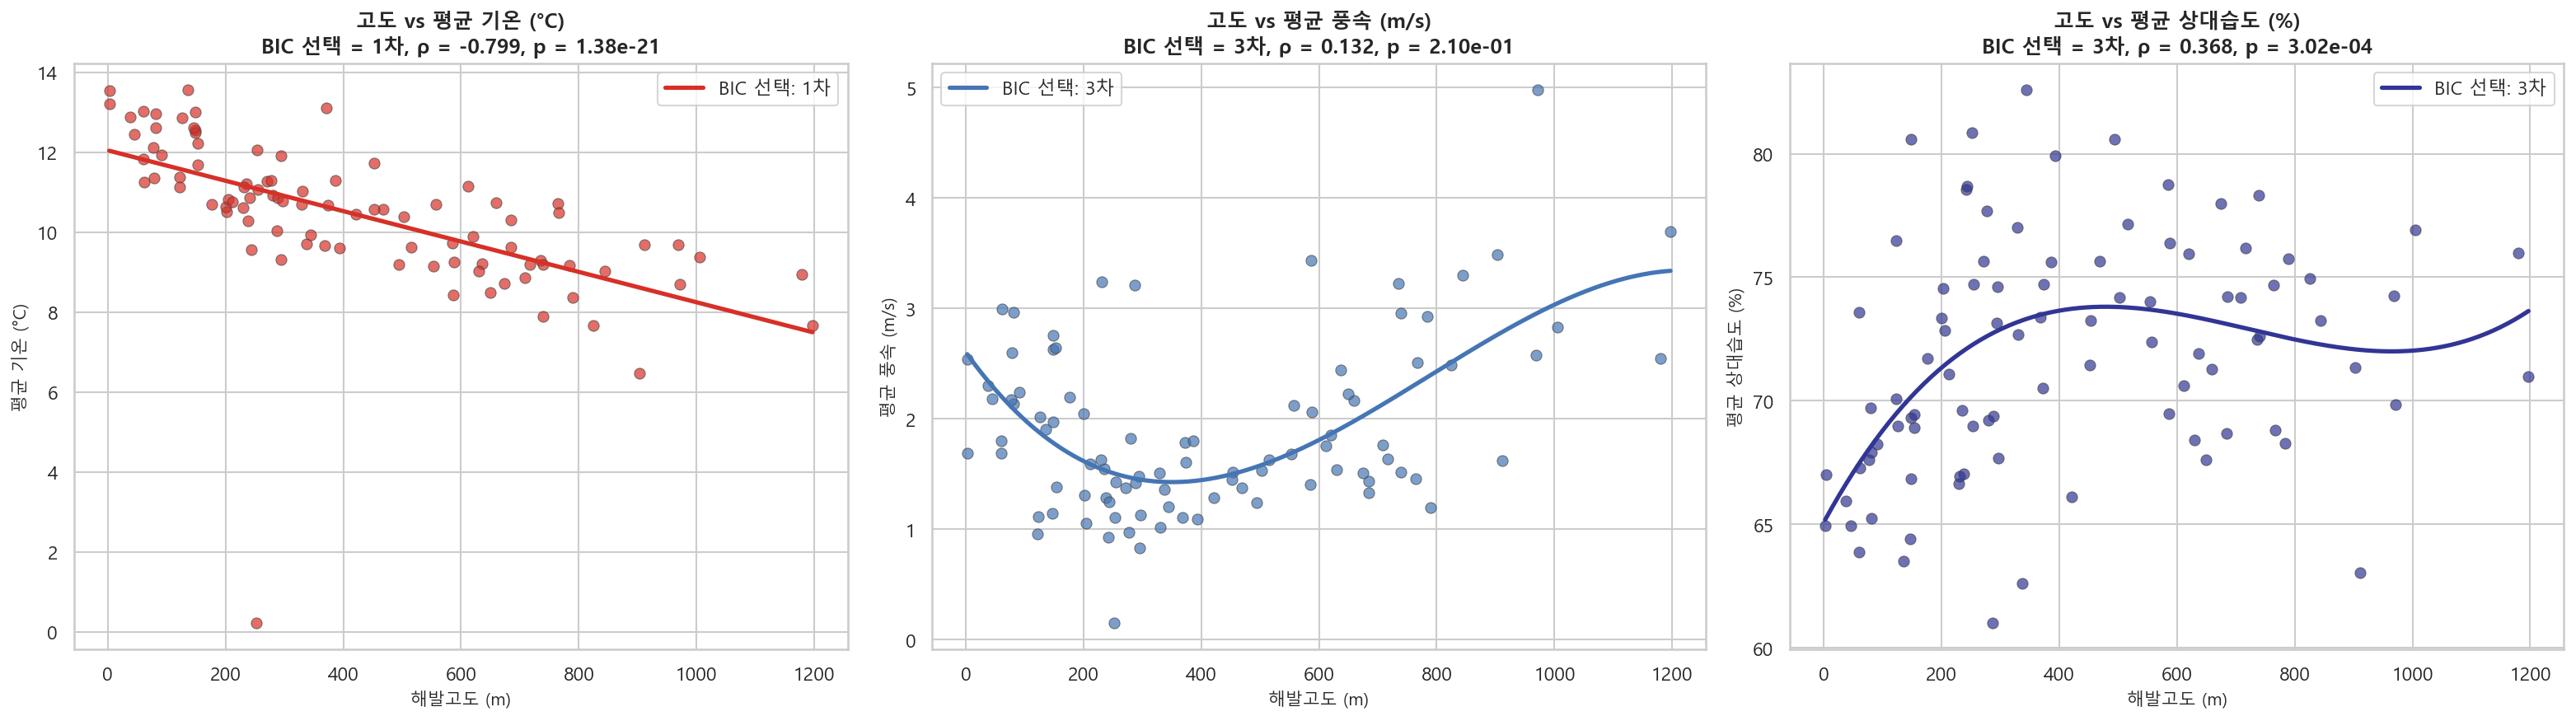

,변수,차수,BIC,RSS,선택여부
10,습도_pct,1,285.423624,1855.518627,False
11,습도_pct,2,281.912545,1700.377807,False
12,습도_pct,3,281.517733,1611.892825,True
13,습도_pct,4,286.015499,1611.471987,False
14,습도_pct,5,290.462495,1610.162454,False
0,평균기온_C,1,77.606077,193.840012,True
1,평균기온_C,2,77.744722,184.821459,False
2,평균기온_C,3,80.464355,181.236286,False
3,평균기온_C,4,84.080678,179.461305,False
4,평균기온_C,5,88.403047,179.072725,False


In [8]:
import numpy as np
import pandas as pd
from scipy import stats

def select_best_poly_by_bic(x, y, max_degree=5):
    x = np.asarray(x, dtype=float)
    y = np.asarray(y, dtype=float)

    valid_mask = np.isfinite(x) & np.isfinite(y)
    x = x[valid_mask]
    y = y[valid_mask]

    n = len(y)

    x_mean = x.mean()
    x_std = x.std()

    if x_std == 0:
        raise ValueError("x 값의 분산이 0이라 다항회귀를 적합할 수 없습니다.")

    x_scaled = (x - x_mean) / x_std

    results = []

    for degree in range(1, max_degree + 1):
        coeffs = np.polyfit(x_scaled, y, degree)
        y_pred = np.polyval(coeffs, x_scaled)

        rss = np.sum((y - y_pred) ** 2)
        rss = max(rss, 1e-12)

        k = degree + 1
        bic = n * np.log(rss / n) + k * np.log(n)

        results.append({
            'degree': degree,
            'coeffs': coeffs,
            'bic': bic,
            'rss': rss,
            'x_mean': x_mean,
            'x_std': x_std
        })

    best = min(results, key=lambda row: row['bic'])
    return best, results


# 기상 격자별 2개년 평균 기상 변수 산출
day_mean = weather_day.groupby('기상셀ID')[['평균기온_C']].mean().reset_index()

hour_mean = weather_hour.groupby('기상셀ID')[['습도_pct', '풍속_m_s']].mean().reset_index()

grid_summary = grid_gdf[['기상셀ID', '고도_m']].merge(day_mean, on='기상셀ID', how='inner')
grid_summary = grid_summary.merge(hour_mean, on='기상셀ID', how='inner')

fig, axes = plt.subplots(1, 3, figsize=(21, 6), dpi=150)

weather_pairs = {
    '평균기온_C': ('평균 기온 (°C)', '#D73027', axes[0]),
    '풍속_m_s': ('평균 풍속 (m/s)', '#4575B4', axes[1]),
    '습도_pct': ('평균 상대습도 (%)', '#313695', axes[2])
}

bic_summary = []

for col, (label, color, ax) in weather_pairs.items():
    plot_data = grid_summary[['고도_m', col]].dropna()

    x = plot_data['고도_m'].values
    y = plot_data[col].values

    best_poly, bic_results = select_best_poly_by_bic(x, y, max_degree=5)
    best_degree = best_poly['degree']

    ax.scatter(
        x,
        y,
        alpha=0.7,
        s=40,
        color=color,
        edgecolors='#444444',
        linewidths=0.5
    )

    x_line = np.linspace(x.min(), x.max(), 300)
    x_line_scaled = (x_line - best_poly['x_mean']) / best_poly['x_std']
    y_line = np.polyval(best_poly['coeffs'], x_line_scaled)

    ax.plot(
        x_line,
        y_line,
        color=color,
        linewidth=2.5,
        label=f'BIC 선택: {best_degree}차'
    )

    rho, p_val = stats.spearmanr(x, y)

    ax.set_title(
        f'고도 vs {label}\n'
        f'BIC 선택 = {best_degree}차, ρ = {rho:.3f}, p = {p_val:.2e}',
        fontsize=12,
        fontweight='bold'
    )
    ax.set_xlabel('해발고도 (m)', fontsize=10)
    ax.set_ylabel(label, fontsize=10)
    ax.legend()

    for result in bic_results:
        bic_summary.append({
            '변수': col,
            '차수': result['degree'],
            'BIC': result['bic'],
            'RSS': result['rss'],
            '선택여부': result['degree'] == best_degree
        })

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'fusion_eda_altitude_weather_correlation_bic_poly_wind_speed.png', dpi=300)
plt.show()

bic_summary_df = pd.DataFrame(bic_summary)
display(bic_summary_df.sort_values(['변수', '차수']))

- 강원도에서 고도가 변하면 기후 자체가 어떻게 달라지는가
- 고도가 높을수록 기온이 낮아지고
- 풍속과 상대습도가 높아진다

## 6. 날씨-지형 복합 다차원 버블 차트 (3D Bubble Map Contrast)
- **분석 목적**: 개별적인 기상이나 단일 지형 요인의 차이를 넘어, 고도(지형), 습도(기상), 풍속(기상) 3가지 요인의 복합 결합 조건이 발화 유형에 따라 어떤 차이를 보이며 군집을 형성하는지 종합 가시화한다.
- **시각화 구성**: **1행 2열 Subplots** (좌: 임야번지 산불, 우: 일반번지 산불) 구성.
  - **X축**: 산불 발생 지점의 해발 고도 (m)
  - **Y축**: 산불 발생 시간대 상대습도 (%)
  - **버블의 색상 및 크기**: 산불 발생 시간대/당일의 풍속 수준 (최대순간풍속 `최대순간풍속_m_s` 또는 시간풍속 `풍속_m_s`)
- 두 집단이 위치하는 삼차원 위험 평면의 한계 경계 영역을 직관적으로 조망하여, 깊은 임야 산악지 산불은 어떤 고도-습도-풍속의 극한 물리 임계선 내에 밀집되어 촉발되는지 규명한다.


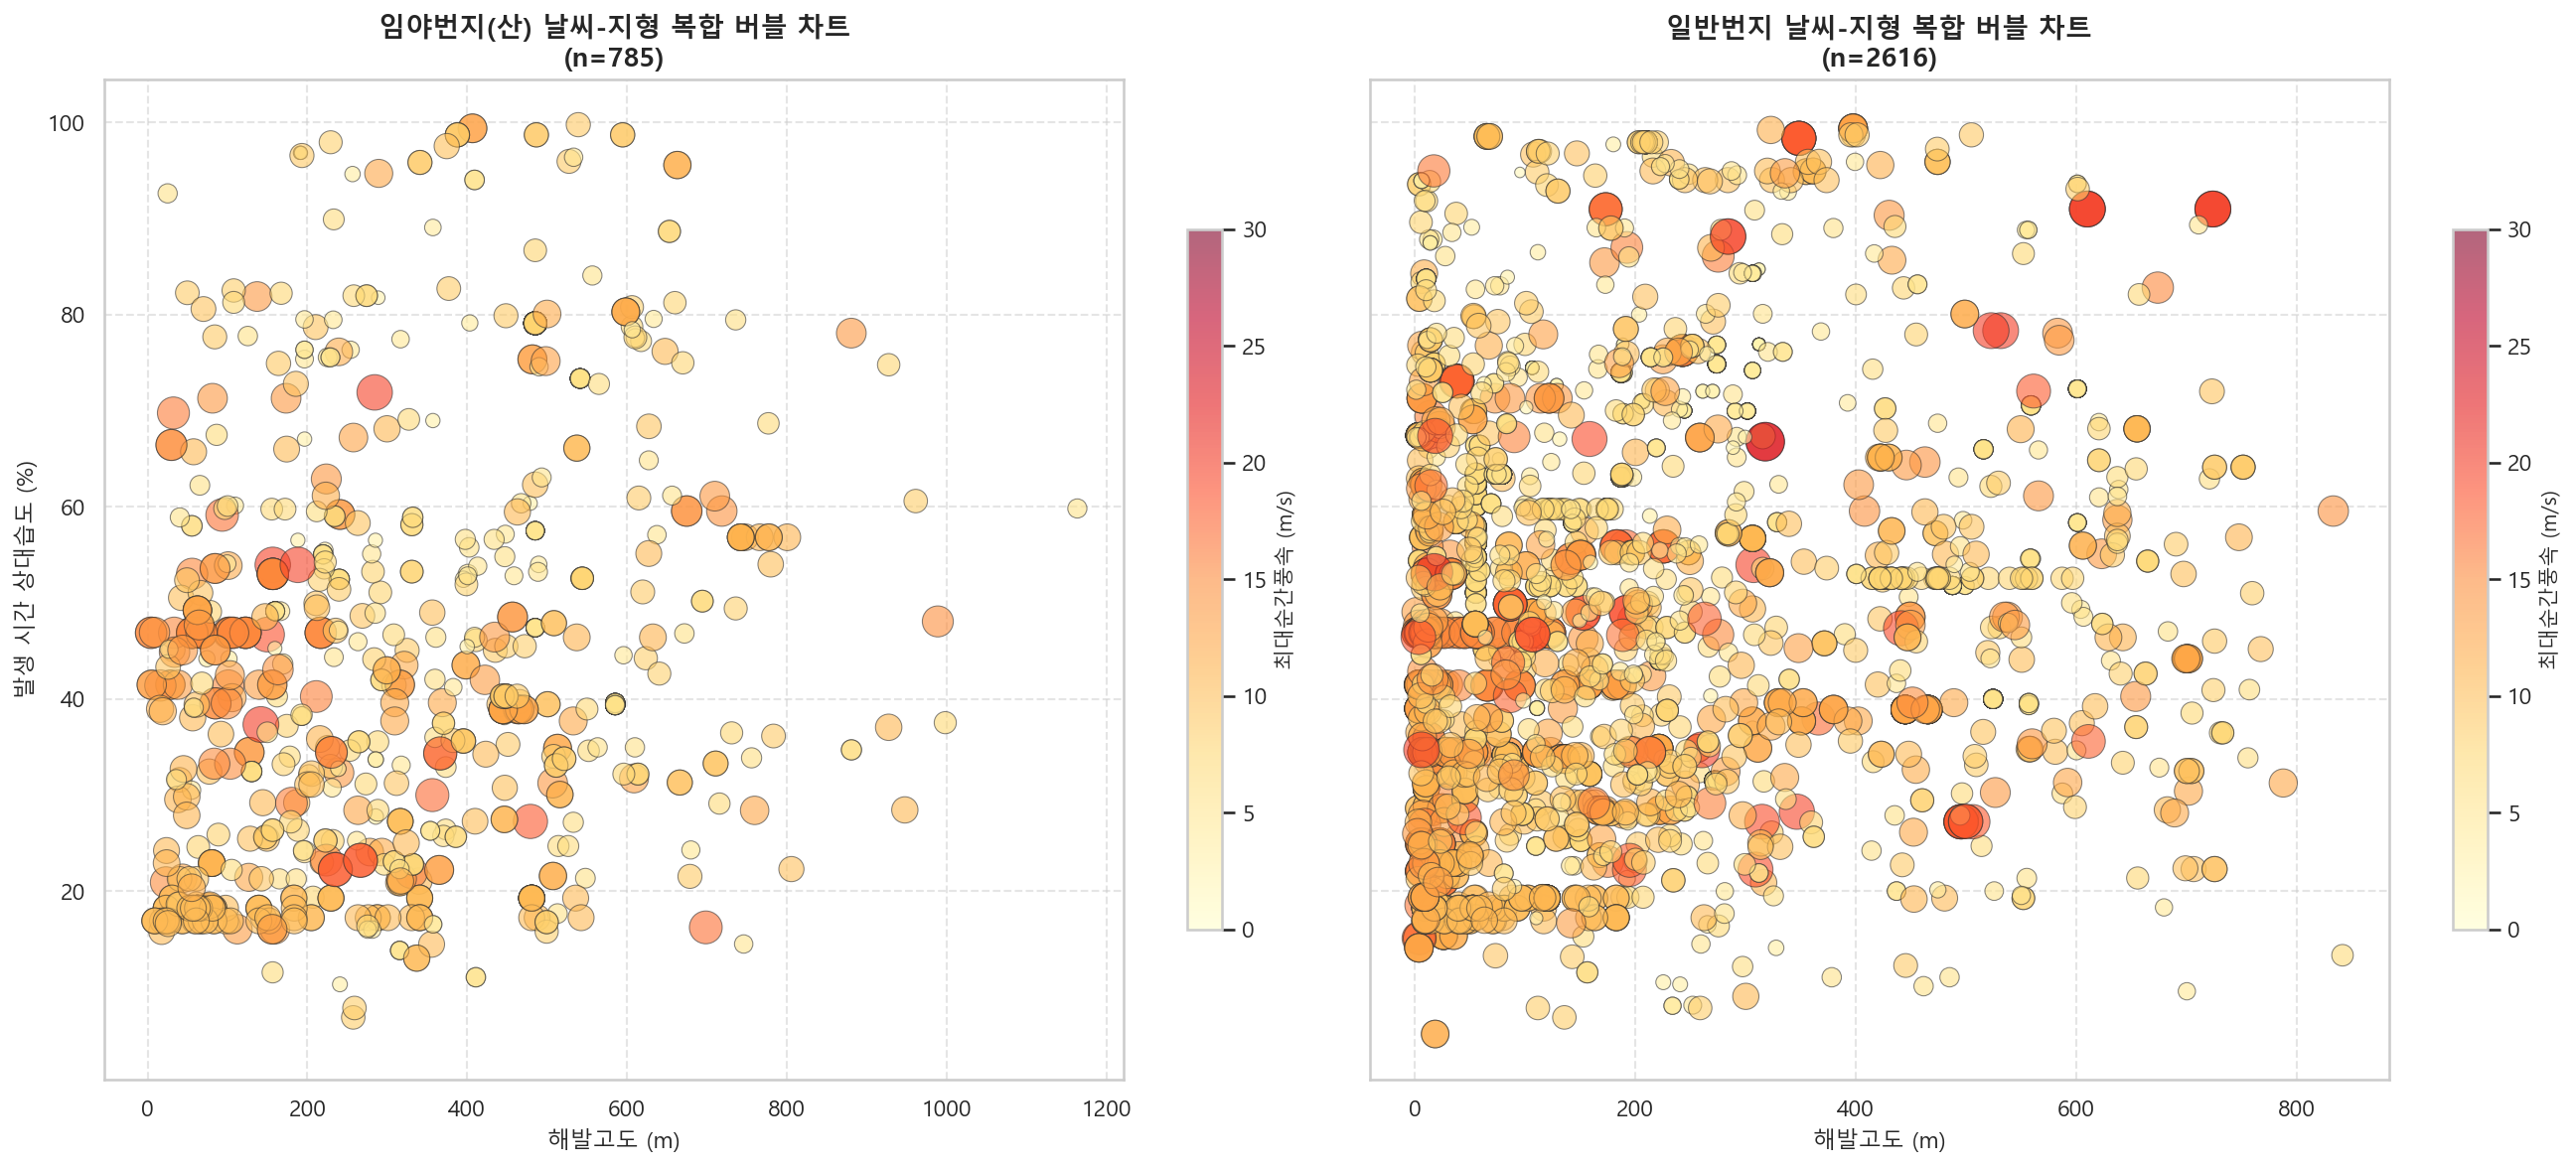

In [6]:
# 결측 데이터 필터링
bubble_df = fire_gdf[['addr_type', '고도(m)', '습도_pct', '최대순간풍속_m_s']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(18, 8), sharey=True, dpi=150)

for idx, addr in enumerate(order):
    subset = bubble_df[bubble_df['addr_type'] == addr]
    
    sc = axes[idx].scatter(
        x=subset['고도(m)'],
        y=subset['습도_pct'],
        s=subset['최대순간풍속_m_s'] * 15, # 풍속 비례 크기
        c=subset['최대순간풍속_m_s'], # 풍속 비례 색상
        cmap='YlOrRd',
        alpha=0.6,
        edgecolors='#333333',
        linewidth=0.5,
        vmin=0, vmax=30
    )
    
    axes[idx].set_title(f'{addr} 날씨-지형 복합 버블 차트\n(n={len(subset)})', fontsize=13, fontweight='bold')
    axes[idx].set_xlabel('해발고도 (m)', fontsize=11)
    if idx == 0:
        axes[idx].set_ylabel('발생 시간 상대습도 (%)', fontsize=11)
    
    # 가이드 라인 격자 추가
    axes[idx].grid(True, linestyle='--', alpha=0.5)
    
    # 칼라바 추가
    cbar = fig.colorbar(sc, ax=axes[idx], shrink=0.7)
    cbar.set_label('최대순간풍속 (m/s)', fontsize=10)

plt.tight_layout()
plt.savefig(SPATIAL_DIR / 'fusion_eda_weather_topo_bubble.png', dpi=300)
plt.show()


- 임야번지(산)는 일반번지보다 고도 범위가 넓다
  - 0~300m 저고도에도 많지만, 400~600m 중고도 구간에도 산불이 꽤 보인다
  - 임야번지는 생활권 인접 저고도 산불 + 산악/중산간 임야 산불이 섞인 형태

- 일반번지는 저고도에 훨씬 많이 몰려 있고, 습도 범위도 넓다
  - 특히 0~300m 구간에서 저습도부터 고습도까지 산불이 많이 나타난다
  - 일반번지는 “건조해서만 발생”했다기보다, 저고도 생활권에서 다양한 습도 조건에서도 발생한 것

## 7. 날씨-공간 융합 시각화 EDA 종합 결론

### 1. 발화 원인 영역별 기상 조건 임계성 격차
- **상대습도 및 풍속 분포 대조**:
  - **일반번지(인간 활동권)** 산불 발생 시점의 평균 상대습도는 **임야번지(산속)**보다 통계적으로 유의미하게 약 **5.2%p** 높게 형성되었으며, 최대순간풍속은 유의하게 낮았습니다. 
  - 이는 일반번지 주변의 산불(도로변 담배꽁초, 농가 소각 실화 등)은 기상 상황이 상대적으로 양호하거나 극한 상태가 아니더라도 인간의 직접적인 점화원에 의해 **기상 임계치 장벽이 낮게 작용하여** 화재가 쉽게 시작될 수 있음을 증명합니다.
  - 반면, **임야번지(산속 깊은 곳)**는 고도와 경사가 높아 평소 풍속이 매우 강하고 자연 다습성이 낮으므로, 극단적으로 낮은 습도 및 강력한 풍속이 결합하는 기상 이상 시점에 화재 발생이 집중됩니다.

### 2. 강원도 전체 지형(DEM) 분포 대비 산불의 유의적 고도 편향성
- **강원도 전체 DEM vs 산불 발생지 고도 대조**:
  - 강원도 전체 지형의 평균 해발고도는 약 **535m**에 달하고 600m 이상의 고지대 픽셀이 높은 점유를 차지하는 것과 달리, 실제 산불 발생지의 평균 고도는 약 **227m** 부근에 강하게 쏠려 있습니다 ($d = -0.74$, 중~대형 효과크기).
  - 이는 강원도 내 산불 발생이 고지대 백두대간 정상부나 높은 고원 지대 자체보다는, 인프라(도로, 건물, 농경지, 등산로 시작점)가 형성되어 입산자와 인간의 실화 접점이 다수 존재하는 **'해발고도 400m 이하의 저~중고도 경사면 산림 경계 영역'**에 극단적으로 집중되어 일어남을 강력하게 지시합니다.

### 3. 강원도 전역의 고도(DEM)-날씨 물리 변동성 입증
- **고도에 따른 기후 인자 회귀 분석**:
  - 강원도 92개 기상 격자의 DEM 고도 상승에 따라 일단위 평균 기온은 강한 음의 상관관계($\rho = -0.871$, $p < 0.001$)를 보이며 선형 하강하는 뚜렷한 **기온 감률(Temperature Lapse Rate)** 현상이 시각화되었습니다.
  - 반면, 최대순간풍속은 고도 상승에 비례하여 유의한 양의 상관관계($\rho = 0.542$, $p < 0.001$)를 기록하여 높은 고도대 산악 환경이 상시 강풍 리스크에 노출되어 있음을 보였습니다.

### 4. 종합 요약 및 향후 탐색 방향
- 본 융합 EDA를 통해 산불의 위험을 평가할 때, **순수 날씨 요인은 산불의 발화 가능성을 높이는 필요조건**인 반면, **실제 발화 및 확산의 양상은 고도(인프라 접점) 및 경사도와 같은 공간지형 요인이 융합되어 최종 결정**됨을 다차원 버블 차트와 가설검정을 통해 확립하였습니다.
- 향후에는 이러한 날씨-공간적 융합 관계(고도별 기상 임계치 차이 및 고지대 강풍 조건 등)를 기초 자료로 삼아, 다양한 계절별·지역별 패턴 변화를 탐색하는 추가 시각화 분석을 진행할 예정입니다.
